# Week 5 · Notebook 3 — Ant Colony Optimization for the TSP

**Goals**
- Define ACO precisely as *iterated sampling from a learned constructive model*: the pheromone matrix $\tau$ and a
  fixed heuristic $\eta$ parameterise a Markov chain over partial tours; evaporation and deposit update $\tau$ from
  sampled solutions.
- Implement, vectorised over ants **and** independent runs, Ant System (Dorigo 1992; Dorigo, Maniezzo & Colorni 1996),
  Ant Colony System (Dorigo & Gambardella 1997) and MAX–MIN Ant System (Stützle & Hoos 2000), including the
  derivation of $\tau_{\max}=1/(\rho L_{\text{best}})$ and of $\tau_{\min}$.
- Validate the sampler against the exact construction probabilities and the algorithms against Held–Karp optima.
- Visualise pheromone learning, study $(\alpha,\beta,\rho)$ over many seeds, and hybridise with 2-opt local search at
  equal cost.

**Prerequisites:** Week 1 (TSP, 2-opt local search, Held–Karp), Week 3 (ILS/VNS: local search inside a metaheuristic),
sampling from discrete distributions.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from utils import random_euclidean_tsp, tour_length, held_karp, bhh_constant_estimate, PALETTE
from scipy.stats import chisquare, mannwhitneyu

## 1. History and the mechanism-level definition

ACO originates in Marco Dorigo's PhD thesis (Politecnico di Milano, **1992**) and the Ant System paper
**Dorigo, Maniezzo & Colorni (1996)**, IEEE Trans. SMC-B 26(1):29–41. The two most influential successors are
**Ant Colony System** (ACS; Dorigo & Gambardella 1997, IEEE TEC 1(1):53–66) and **MAX–MIN Ant System** (MMAS; Stützle &
Hoos 2000, Future Generation Computer Systems 16(8):889–914). The unifying *ACO metaheuristic* is described in
Dorigo & Stützle, *Ant Colony Optimization* (MIT Press, 2004).

**Mechanisms.** A *solution* is built by a constructive stochastic process: ant $k$ at city $i$ with unvisited set
$\mathcal N_i^k$ moves to $j$ with probability

$$
p_{ij}^k=\frac{\tau_{ij}^{\alpha}\,\eta_{ij}^{\beta}}{\sum_{l\in\mathcal N_i^k}\tau_{il}^{\alpha}\,\eta_{il}^{\beta}},
\qquad \eta_{ij}=1/d_{ij}.
$$

The **memory** is the pheromone matrix $\tau$ (a learned, shared, *distributional* memory — unlike PSO's point
memories). The **update** is evaporation plus reinforcement:

$$
\tau_{ij}\leftarrow(1-\rho)\,\tau_{ij}+\sum_{k\in\mathcal U}\Delta\tau_{ij}^k,\qquad
\Delta\tau^k_{ij}=\begin{cases}1/L_k & (i,j)\in T_k\\ 0&\text{otherwise,}\end{cases}
$$

where the set $\mathcal U$ of depositing ants is all ants (AS), the best-so-far ant (ACS) or the iteration-best ant
(MMAS). $\alpha$ weighs learned information, $\beta$ the greedy heuristic, $\rho$ the forgetting rate.

| variant | construction | deposit | extra mechanism |
|---|---|---|---|
| AS | random-proportional | all $m$ ants, $1/L_k$ | none; $\tau_0=m/C^{nn}$ |
| ACS | *pseudo-random proportional*: with prob. $q_0$ take $\arg\max_j\tau_{ij}\eta_{ij}^{\beta}$ | best-so-far only, $\tau\leftarrow(1-\rho)\tau+\rho/L_{bs}$ on its edges | *local update* $\tau_{ij}\leftarrow(1-\xi)\tau_{ij}+\xi\tau_0$ while building, $\tau_0=1/(nC^{nn})$ |
| MMAS | random-proportional | iteration-best | bounds $[\tau_{\min},\tau_{\max}]$, init at $\tau_{\max}$, restarts |

```text
ACO(D, m, iterations)
  tau = tau0 everywhere; eta = 1/D
  repeat:
    for each ant k (in parallel): start at a random city; repeatedly pick the next city with p_ij ∝ tau^a eta^b
                                   (ACS: greedy with prob q0; apply local update on the edge just used)
    optionally improve each tour by local search (2-opt)
    evaporate: tau *= (1 - rho)           (ACS: only on the best-so-far edges)
    deposit 1/L on the edges of the selected tours; (MMAS: clip tau to [tau_min, tau_max]; restart on stagnation)
  return best tour
```

*AI relevance.* The same "learn a distribution over constructive decisions from sampled solutions" loop underlies
policy-gradient methods for combinatorial optimisation (e.g. neural construction heuristics for routing trained with
REINFORCE) — Notebook 4 makes the link to stochastic gradient ascent precise.

## 2. MMAS pheromone bounds

**$\tau_{\max}$.** Suppose an edge receives the deposit $1/L$ in every iteration. Then
$\tau_{t+1}=(1-\rho)\tau_t+1/L$, a contraction with unique fixed point

$$
\tau^{\ast}=\frac{1}{\rho L}=\sum_{k\ge0}(1-\rho)^k\frac1L ,
$$

and $|\tau_t-\tau^{\ast}|=(1-\rho)^t|\tau_0-\tau^{\ast}|$. In MMAS one ant deposits $1/L\le1/L_{\text{opt}}$ per
iteration, so by the same recursion every pheromone value is asymptotically bounded by $1/(\rho L_{\text{opt}})$.
The optimum is unknown, so MMAS uses $\tau_{\max}=1/(\rho L_{\text{bs}})$ with the best-so-far length, updated
whenever $L_{\text{bs}}$ improves (Stützle & Hoos 2000; they parameterise the update by the persistence, which is
our $1-\rho$).

**$\tau_{\min}$.** At convergence the best tour's edges carry $\tau_{\max}$, all others $\tau_{\min}$. Ignoring $\eta$
($\alpha=1$) and assuming on average $\text{avg}$ candidate cities per decision, a decision picks the $\tau_{\max}$ edge
with probability $p_{\text{dec}}=\tau_{\max}/(\tau_{\max}+(\text{avg}-1)\tau_{\min})$. Requiring the whole tour
($n$ decisions) to be re-sampled with probability $p_{\text{best}}$ gives $p_{\text{dec}}=p_{\text{best}}^{1/n}$ and

$$
\tau_{\min}=\frac{\tau_{\max}\,(1-p_{\text{best}}^{1/n})}{(\text{avg}-1)\,p_{\text{best}}^{1/n}},\qquad \text{avg}=n/2 .
$$

We verify both statements numerically.

In [2]:
rho_, L_ = 0.02, 5.3
t_seq = [0.0]
for _ in range(2000):
    t_seq.append((1 - rho_) * t_seq[-1] + 1 / L_)
check_close(t_seq[-1], 1 / (rho_ * L_), "pheromone after 2000 constant deposits vs 1/(rho L)", rtol=1e-12, atol=1e-12)
check_close(abs(t_seq[100] - 1 / (rho_ * L_)), (1 - rho_) ** 100 / (rho_ * L_), "geometric error |tau_100 - tau*|", rtol=1e-9)

def tau_bounds(L_bs, rho, n, p_best=0.05):
    tmax = 1.0 / (rho * L_bs)
    pdec = p_best ** (1.0 / n)
    return tmax, tmax * (1 - pdec) / ((n / 2 - 1) * pdec)

n_ = 30
tmax, tmin = tau_bounds(4.0, 0.02, n_)
p_dec = tmax / (tmax + (n_ / 2 - 1) * tmin)
check_close(p_dec**n_, 0.05, "converged MMAS re-samples its best tour with probability p_best", rtol=1e-10)

[PASS] pheromone after 2000 constant deposits vs 1/(rho L): got 9.433962, expected 9.433962
[PASS] geometric error |tau_100 - tau*|: got 1.251128, expected 1.251128
[PASS] converged MMAS re-samples its best tour with probability p_best: got 0.05, expected 0.05


## 3. Vectorised implementation

Everything is vectorised over `runs` independent colonies (`tau` has shape `(runs, n, n)`) and over the `m` ants of
each colony; a construction step is one gather `W[run, current_city, :]`, a mask of visited cities and an inverse-CDF
draw per ant. Evaluation counting: one *tour* = one objective evaluation.

Implementation notes. (i) In ACS the local update is applied after each construction step to the edges all ants
just used, in parallel (the original description updates ant by ant; when two ants use the same edge in the same
step we apply the update once). (ii) MMAS restarts (re-initialise $\tau\leftarrow\tau_{\max}$) after
`restart_after` iterations without improvement of the best-so-far tour — a simplification of the branching-factor
criterion of Stützle & Hoos. (iii) $\eta_{ii}=0$ so a city is never chosen twice.

**2-opt** uses the standard speed-ups of Bentley (1992): first improvement, *neighbour lists* (only the $K=10$ nearest
cities are tried as new neighbours; a move is skipped as soon as $d_{ac}\ge d_{ab}$, which loses no improving move
when $K=n-1$) and *don't-look bits* (a city is re-examined only after one of its tour edges changed).

In [3]:
def nearest_neighbour_length(D, start=0):
    n = len(D); tour = [start]; left = set(range(n)) - {start}
    while left:
        j = min(left, key=lambda c: D[tour[-1], c]); tour.append(j); left.remove(j)
    return tour_length(tour, D)


def sample_next(w, rng, q0=0.0):
    """Row-wise draw from unnormalised weights w (..., n); with prob q0 take the argmax instead."""
    cum = np.cumsum(w, axis=-1)
    u = rng.random(w.shape[:-1]) * cum[..., -1]
    nxt = (cum <= u[..., None]).sum(-1)
    if q0 > 0:
        greedy = rng.random(w.shape[:-1]) < q0
        nxt = np.where(greedy, w.argmax(-1), nxt)
    return nxt


def construct_tours(W, m, rng, q0=0.0, local=None):
    """Build m tours per run from weights W (runs, n, n). local=(tau, eta_b, alpha, xi, tau0) enables ACS local update."""
    R, n, _ = W.shape
    tours = np.empty((R, m, n), dtype=int)
    cur = rng.integers(0, n, (R, m))
    tours[:, :, 0] = cur
    unvisited = np.ones((R, m, n), bool)
    rr, mm = np.arange(R)[:, None], np.arange(m)[None, :]
    unvisited[rr, mm, cur] = False
    for s in range(1, n):
        w = W[rr, cur] * unvisited
        dead = w.sum(-1) <= 0                          # numerical underflow guard
        if dead.any():
            w[dead] = unvisited[dead]
        nxt = sample_next(w, rng, q0)
        if local is not None:                          # ACS local pheromone update on the edges just used
            tau, eta_b, alpha, xi, tau0 = local
            new = (1 - xi) * tau[rr, cur, nxt] + xi * tau0
            tau[rr, cur, nxt] = new; tau[rr, nxt, cur] = new
            W[rr, cur, nxt] = new**alpha * eta_b[cur, nxt]; W[rr, nxt, cur] = W[rr, cur, nxt]
        tours[:, :, s] = nxt
        unvisited[rr, mm, nxt] = False
        cur = nxt
    if local is not None:                              # closing edge back to the start city
        tau, eta_b, alpha, xi, tau0 = local
        st = tours[:, :, 0]
        new = (1 - xi) * tau[rr, cur, st] + xi * tau0
        tau[rr, cur, st] = new; tau[rr, st, cur] = new
    return tours


def tour_lengths(tours, D):
    return D[tours, np.roll(tours, -1, axis=-1)].sum(-1)


def deposit(tau, tours, amount):
    """Add amount (runs, k) on both directions of every edge of tours (runs, k, n)."""
    R, k, n = tours.shape
    a, b = tours, np.roll(tours, -1, axis=-1)
    rix = np.broadcast_to(np.arange(R)[:, None, None], a.shape)
    amt = np.broadcast_to(amount[..., None], a.shape)
    np.add.at(tau, (rix, a, b), amt)
    np.add.at(tau, (rix, b, a), amt)


def neighbour_lists(D, K):
    order = np.argsort(D, axis=1)
    return [list(map(int, row[row != i][:K])) for i, row in enumerate(order)]

def two_opt_nl(tour, D, nbrs):
    """First-improvement 2-opt with neighbour lists and don't-look bits (Bentley 1992).
    Returns (tour, number of move evaluations, sum of accepted deltas)."""
    t = [int(c) for c in tour]; n = len(t)
    pos = [0] * n
    for i, c in enumerate(t):
        pos[c] = i
    Dl = D.tolist()
    def reverse(i, j):                      # reverse the cyclic segment t[i..j]
        L = (j - i) % n + 1
        for k in range(L // 2):
            a, b = (i + k) % n, (j - k) % n
            t[a], t[b] = t[b], t[a]
            pos[t[a]], pos[t[b]] = a, b
    active = list(range(n)); dlb = [False] * n
    evals, gain = 0, 0.0
    while active:
        a = active.pop()
        if dlb[a]:
            continue
        improved = False
        for succ in (True, False):
            ia = pos[a]
            b = t[(ia + 1) % n] if succ else t[(ia - 1) % n]
            d_ab = Dl[a][b]
            for c in nbrs[a]:
                d_ac = Dl[a][c]
                if d_ac >= d_ab:
                    break
                ic = pos[c]
                d = t[(ic + 1) % n] if succ else t[(ic - 1) % n]
                if c == b or d == a:
                    continue
                evals += 1
                delta = d_ac + Dl[b][d] - d_ab - Dl[c][d]
                if delta < -1e-12:
                    if succ:
                        reverse(ia + 1, ic)          # a b ... c d -> a c ... b d
                    else:
                        reverse(ic, ia - 1)          # d c ... b a -> d b ... c a
                    gain += delta
                    for x in (a, b, c, d):
                        if dlb[x] or x not in active:
                            dlb[x] = False; active.append(x)
                    improved = True
                    break
            if improved:
                break
        if not improved:
            dlb[a] = True
    return np.array(t), evals, gain


def aco_tsp(D, variant="MMAS", runs=1, iters=100, m=None, alpha=1.0, beta=2.0, rho=None, q0=0.9, xi=0.1,
            p_best=0.05, restart_after=100, local_search=False, rng=None, snapshots=(), max_cost=np.inf):
    """AS / ACS / MMAS for the symmetric TSP, vectorised over independent runs.

    Returns dict with best lengths/tours per run, best-so-far per iteration (runs, iters), the cumulative cost per
    run (runs, iters) in tour evaluations (plus 2-opt move evaluations * 4/n when local_search) and optional
    pheromone snapshots. Stops early once every run has spent max_cost.
    """
    rng = np.random.default_rng() if rng is None else rng
    n = len(D)
    m = (10 if variant == "ACS" else n) if m is None else m
    rho = {"AS": 0.5, "ACS": 0.1, "MMAS": 0.02}[variant] if rho is None else rho
    eta = 1.0 / (D + np.eye(n)); np.fill_diagonal(eta, 0.0)
    eta_b = eta**beta
    Cnn = nearest_neighbour_length(D)
    tau0 = {"AS": m / Cnn, "ACS": 1.0 / (n * Cnn), "MMAS": 1.0 / (rho * Cnn)}[variant]
    tau = np.full((runs, n, n), tau0)
    best_len, best_tour = np.full(runs, np.inf), np.zeros((runs, n), dtype=int)
    last_imp = np.zeros(runs, dtype=int)
    nbrs = neighbour_lists(D, min(10, n - 1)) if local_search else None
    hist, cost, cost_hist, snaps = [], np.zeros(runs), [], {}
    rr = np.arange(runs)
    for it in range(iters):
        if it in snapshots:
            snaps[it] = tau[0].copy()
        W = tau**alpha * eta_b
        if variant == "ACS":
            tours = construct_tours(W, m, rng, q0=q0, local=(tau, eta_b, alpha, xi, tau0))
        else:
            tours = construct_tours(W, m, rng)
        L = tour_lengths(tours, D)
        cost += m
        if local_search:
            for r in range(runs):
                for k in range(m):
                    tours[r, k], ev, _ = two_opt_nl(tours[r, k], D, nbrs)
                    cost[r] += ev * 4.0 / n
            L = tour_lengths(tours, D)
        ib = L.argmin(1)
        L_ib, T_ib = L[rr, ib], tours[rr, ib]
        imp = L_ib < best_len - 1e-12
        best_len[imp], best_tour[imp], last_imp[imp] = L_ib[imp], T_ib[imp], it
        # ---- pheromone update
        if variant == "AS":
            tau *= 1 - rho
            deposit(tau, tours, 1.0 / L)
        elif variant == "ACS":
            a, b = best_tour, np.roll(best_tour, -1, axis=1)
            ri = np.broadcast_to(rr[:, None], a.shape)
            new = (1 - rho) * tau[ri, a, b] + rho / best_len[:, None]
            tau[ri, a, b] = new; tau[ri, b, a] = new
        else:  # MMAS
            tau *= 1 - rho
            deposit(tau, T_ib[:, None, :], 1.0 / L_ib[:, None])
            tmax, tmin = tau_bounds(best_len, rho, n, p_best)
            tau = np.clip(tau, tmin[:, None, None], tmax[:, None, None])
            stale = it - last_imp >= restart_after
            if stale.any():
                tau[stale] = tmax[stale, None, None]
                last_imp[stale] = it
        hist.append(best_len.copy()); cost_hist.append(cost.copy())
        if cost.min() >= max_cost:
            break
    return dict(best_len=best_len, best_tour=best_tour, hist=np.array(hist).T, cost=np.array(cost_hist).T,
                tau=tau, snaps=snaps)

## 4. Validation

**(a) The sampler realises $p_{ij}$ exactly.** For a fixed random $\tau$ and a fixed partial tour we draw the next
city $2\times10^5$ times and compare the frequencies with the analytic probabilities (Pearson $\chi^2$ test), for the
random-proportional rule and for ACS's pseudo-random proportional rule, whose probabilities are
$q_0\,\mathbb 1[j=j^{\ast}]+(1-q_0)\,p_{ij}$.

In [4]:
pts12, D12 = random_euclidean_tsp(12, np.random.default_rng(5))
eta12 = 1.0 / (D12 + np.eye(12)); np.fill_diagonal(eta12, 0)
tau12 = np.random.default_rng(6).uniform(0.5, 2.0, (12, 12))
i0, visited = 3, [3, 7, 0]
mask = np.ones(12, bool); mask[visited] = False
w_row = tau12[i0] ** 1.0 * eta12[i0] ** 2.0 * mask
p_exact = w_row / w_row.sum()
Ndraw = 200_000
draws = sample_next(np.broadcast_to(w_row, (Ndraw, 12)), np.random.default_rng(7))
freq = np.bincount(draws, minlength=12)
check_true(freq[~mask].sum() == 0, "visited cities are never sampled")
pval = chisquare(freq[mask], Ndraw * p_exact[mask]).pvalue
print(f"random-proportional rule: chi-square p-value = {pval:.3f}")
check_true(pval > 1e-3, "sampled frequencies are consistent with p_ij = tau^a eta^b / sum")
q0_ = 0.9
p_acs = (1 - q0_) * p_exact; p_acs[np.argmax(w_row)] += q0_
draws = sample_next(np.broadcast_to(w_row, (Ndraw, 12)), np.random.default_rng(8), q0=q0_)
pval = chisquare(np.bincount(draws, minlength=12)[mask], Ndraw * p_acs[mask]).pvalue
print(f"pseudo-random proportional rule: chi-square p-value = {pval:.3f}")
check_true(pval > 1e-3, "ACS rule: frequencies consistent with q0*1[j=argmax] + (1-q0)*p_ij")

[PASS] visited cities are never sampled
random-proportional rule: chi-square p-value = 0.121
[PASS] sampled frequencies are consistent with p_ij = tau^a eta^b / sum
pseudo-random proportional rule: chi-square p-value = 0.333
[PASS] ACS rule: frequencies consistent with q0*1[j=argmax] + (1-q0)*p_ij


**(b) Tours are permutations; 2-opt is correct.** With full neighbour lists ($K=n-1$) the 2-opt output must be
2-optimal, which we check with an independent explicit double loop over all $n(n-3)/2$ moves; for every run the sum
of accepted move gains must equal the recomputed change of tour length.

In [5]:
tours_chk = construct_tours(np.random.default_rng(1).random((4, 12, 12)), 7, np.random.default_rng(2))
check_true(all(sorted(t) == list(range(12)) for t in tours_chk.reshape(-1, 12)), "every constructed tour is a permutation")
pts50, D50 = random_euclidean_tsp(50, np.random.default_rng(3))
t_rand = np.random.default_rng(4).permutation(50)
for K in [49, 10]:
    t_opt, ev, gain = two_opt_nl(t_rand, D50, neighbour_lists(D50, K))
    check_close(tour_length(t_opt, D50) - tour_length(t_rand, D50), gain, f"K={K}: sum of move gains = length change", atol=1e-9)
    check_true(sorted(t_opt) == list(range(50)), f"K={K}: 2-opt output is a permutation ({ev} move evaluations)")
t_opt, _, _ = two_opt_nl(t_rand, D50, neighbour_lists(D50, 49))
best_gain = min(D50[t_opt[i], t_opt[j]] + D50[t_opt[(i + 1) % 50], t_opt[(j + 1) % 50]]
                - D50[t_opt[i], t_opt[(i + 1) % 50]] - D50[t_opt[j], t_opt[(j + 1) % 50]]
                for i in range(50) for j in range(i + 2, 50) if not (i == 0 and j == 49))
check_true(best_gain > -1e-12, f"full neighbour lists: no improving 2-opt move remains (best delta {best_gain:.2e})")

[PASS] every constructed tour is a permutation
[PASS] K=49: sum of move gains = length change: got -15.809089, expected -15.809089
[PASS] K=49: 2-opt output is a permutation (413 move evaluations)
[PASS] K=10: sum of move gains = length change: got -15.809089, expected -15.809089
[PASS] K=10: 2-opt output is a permutation (409 move evaluations)
[PASS] full neighbour lists: no improving 2-opt move remains (best delta 1.62e-03)


**(c) Exact optima.** Five random Euclidean instances with $n=13$ are solved exactly by Held–Karp
($O(n^22^n)$ dynamic programming). Each ACO variant gets 10 independent runs of 1500 tour constructions.

In [6]:
BUDGET_TOURS = 1500
hk_rows = []
for inst in range(5):
    _, Dk = random_euclidean_tsp(13, np.random.default_rng(100 + inst))
    opt, opt_tour = held_karp(Dk)
    check_close(tour_length(opt_tour, Dk), opt, f"instance {inst}: Held-Karp tour length equals its reported optimum", atol=1e-9)
    row = [opt]
    for k, var in enumerate(["AS", "ACS", "MMAS"]):
        mk = 10 if var == "ACS" else 13
        r = aco_tsp(Dk, var, runs=10, iters=BUDGET_TOURS // mk, m=mk, rng=np.random.default_rng(10 * inst + k))
        row.append(r["best_len"] / opt - 1)
    hk_rows.append(row)
print(f"{'inst':>4s} {'optimum':>8s}" + "".join(f"{v:>22s}" for v in ["AS", "ACS", "MMAS"]))
for inst, row in enumerate(hk_rows):
    print(f"{inst:4d} {row[0]:8.4f}" + "".join(f"   hit {np.mean(g < 1e-9):4.0%}, max gap {g.max():5.2%}" for g in row[1:]))
hit = {v: np.mean([np.mean(row[1 + k] < 1e-9) for row in hk_rows]) for k, v in enumerate(["AS", "ACS", "MMAS"])}
print("overall fraction of runs that found the Held-Karp optimum:", {k: f"{v:.0%}" for k, v in hit.items()})
check_true(min(g.min() for row in hk_rows for g in row[1:]) > -1e-9, "no ACO tour is shorter than the Held-Karp optimum")
check_true(hit["ACS"] >= 0.9 and hit["MMAS"] >= 0.9, "ACS and MMAS find the exact optimum in >= 90% of runs (n=13)")

[PASS] instance 0: Held-Karp tour length equals its reported optimum: got 2.922774, expected 2.922774


[PASS] instance 1: Held-Karp tour length equals its reported optimum: got 3.433916, expected 3.433916


[PASS] instance 2: Held-Karp tour length equals its reported optimum: got 3.264973, expected 3.264973


[PASS] instance 3: Held-Karp tour length equals its reported optimum: got 3.293226, expected 3.293226


[PASS] instance 4: Held-Karp tour length equals its reported optimum: got 3.019214, expected 3.019214


inst  optimum                    AS                   ACS                  MMAS
   0   2.9228   hit 100%, max gap 0.00%   hit 100%, max gap 0.00%   hit  90%, max gap 2.03%
   1   3.4339   hit  90%, max gap 0.51%   hit  90%, max gap 0.51%   hit  80%, max gap 0.51%
   2   3.2650   hit 100%, max gap 0.00%   hit 100%, max gap 0.00%   hit 100%, max gap 0.00%
   3   3.2932   hit  80%, max gap 0.19%   hit 100%, max gap 0.00%   hit 100%, max gap 0.00%
   4   3.0192   hit 100%, max gap 0.00%   hit 100%, max gap 0.00%   hit  90%, max gap 0.11%
overall fraction of runs that found the Held-Karp optimum: {'AS': '94%', 'ACS': '98%', 'MMAS': '92%'}
[PASS] no ACO tour is shorter than the Held-Karp optimum
[PASS] ACS and MMAS find the exact optimum in >= 90% of runs (n=13)


## 5. Watching the pheromone model learn

MMAS on a 40-city instance (one run, $\rho=0.02$, 400 iterations, no restarts). The red overlay is the best tour found at the end. The model starts
uniform (all edges at $\tau_{\max}$), and evaporation plus iteration-best deposit progressively concentrate the
probability mass on a few edges per city — the pheromone matrix *is* the search distribution. With $\rho=0.02$ this
learning is slow: little changes during the first 100 iterations (compare the parameter study below). Edge opacity is
proportional to the pheromone-only choice probability $\tau_{ij}/\sum_l\tau_{il}$ (symmetrised).

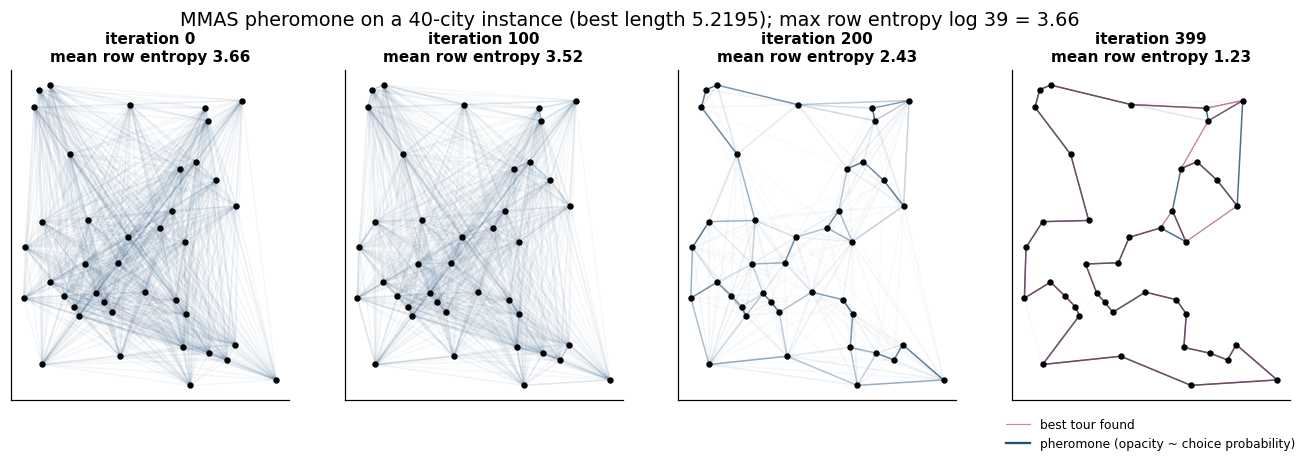

In [7]:
pts40, D40 = random_euclidean_tsp(40, np.random.default_rng(40))
snap_its = (0, 100, 200, 399)
r40 = aco_tsp(D40, "MMAS", runs=1, iters=400, rng=np.random.default_rng(41), snapshots=snap_its, restart_after=10**9)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.9))
iu = np.triu_indices(40, 1)
for ax, it in zip(axes, snap_its):
    T = r40["snaps"][it].copy(); np.fill_diagonal(T, 0.0)
    Pr = T / T.sum(1, keepdims=True); Psym = (Pr + Pr.T) / 2          # pheromone-only choice probabilities
    for e in range(len(iu[0])):
        i, j = iu[0][e], iu[1][e]
        a_ = min(1.0, 2.0 * Psym[i, j])                                  # uniform rows (p = 1/39) are drawn faintly
        if a_ > 0.02:
            ax.plot(pts40[[i, j], 0], pts40[[i, j], 1], color=PALETTE["blue"], alpha=a_, lw=1.0)
    ax.scatter(*pts40.T, s=10, color="k", zorder=3)
    ent = -np.mean([(p := T[i][np.arange(40) != i] / T[i][np.arange(40) != i].sum()) @ np.log(p) for i in range(40)])
    ax.set_title(f"iteration {it}\nmean row entropy {ent:.2f}", fontsize=10); ax.set_xticks([]); ax.set_yticks([])
bt = r40["best_tour"][0]
axes[-1].plot(pts40[np.r_[bt, bt[0]], 0], pts40[np.r_[bt, bt[0]], 1], color=PALETTE["red"], lw=0.8, alpha=0.6, label="best tour found")
axes[-1].plot([], [], color=PALETTE["blue"], label="pheromone (opacity ~ choice probability)")
axes[-1].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.suptitle(f"MMAS pheromone on a 40-city instance (best length {r40['best_len'][0]:.4f}); max row entropy log 39 = {np.log(39):.2f}", y=1.02)
savefig("w5_aco_pheromone_evolution.png"); plt.show()

## 6. Parameter study: $\alpha$, $\beta$, $\rho$ (Ant System and MMAS)

Instance: 40 random cities (the one above). Reference: the best tour found by 4 MMAS + 2-opt runs of 50 iterations — a
*best-known* value, not a proven optimum; the BHH asymptotic estimate $0.7124\sqrt{n}$ is printed only as a
sanity check of scale. Each setting: 10 independent runs, 4000 tour constructions, one parameter varied at a time
around AS defaults $(\alpha,\beta,\rho)=(1,2,0.5)$ and MMAS defaults $(1,2,0.02)$.

In [8]:
ref = aco_tsp(D40, "MMAS", runs=4, iters=50, m=10, rho=0.2, local_search=True, rng=np.random.default_rng(42))
L_ref = min(ref["best_len"].min(), r40["best_len"][0])
print(f"best-known length L_ref = {L_ref:.4f}  (BHH estimate {bhh_constant_estimate(40):.3f}; "
      f"{np.mean(ref['best_len'] < L_ref + 1e-9):.0%} of the reference runs reached it)")

def study(variant, base, name, values, iters=100, runs=10, seed=0):
    out = []
    for v in values:
        kw = dict(base); kw[name] = v
        r = aco_tsp(D40, variant, runs=runs, iters=iters, rng=np.random.default_rng(seed), **kw)
        out.append(100 * (r["best_len"] / L_ref - 1))
    return out

grids = {"alpha": [0.5, 1, 2, 4], "beta": [0, 1, 2, 3, 5], "rho": [0.02, 0.1, 0.5, 0.9]}
base = {"AS": dict(alpha=1.0, beta=2.0, rho=0.5), "MMAS": dict(alpha=1.0, beta=2.0, rho=0.02)}
study_res = {(var, p): study(var, base[var], p, vals, seed=7) for var in ["AS", "MMAS"] for p, vals in grids.items()}
for (var, p), gaps in study_res.items():
    print(f"{var:4s} {p:5s}: " + "  ".join(f"{v}: {np.median(g):5.2f}% [{np.percentile(g, 25):.2f},{np.percentile(g, 75):.2f}]"
                                          for v, g in zip(grids[p], gaps)))

best-known length L_ref = 5.2164  (BHH estimate 4.506; 100% of the reference runs reached it)


AS   alpha: 0.5: 15.67% [13.63,16.42]  1:  0.69% [0.59,0.69]  2:  4.06% [2.97,5.87]  4:  7.06% [6.12,8.01]
AS   beta : 0: 175.98% [169.25,178.74]  1:  7.54% [6.04,9.33]  2:  0.69% [0.59,0.69]  3:  0.50% [0.50,0.69]  5:  0.56% [0.50,0.62]
AS   rho  : 0.02:  6.22% [5.26,6.83]  0.1:  0.95% [0.70,1.40]  0.5:  0.69% [0.59,0.69]  0.9:  0.50% [0.50,0.69]
MMAS alpha: 0.5: 38.66% [36.27,40.53]  1: 28.68% [25.75,31.23]  2: 10.17% [9.35,12.05]  4:  2.61% [1.46,3.36]
MMAS beta : 0: 178.14% [173.67,182.14]  1: 76.76% [71.74,78.57]  2: 28.68% [25.75,31.23]  3: 10.27% [9.22,13.14]  5:  1.43% [1.40,1.61]
MMAS rho  : 0.02: 28.68% [25.75,31.23]  0.1:  1.09% [0.71,1.50]  0.5:  2.00% [0.95,3.42]  0.9:  3.06% [2.09,3.63]


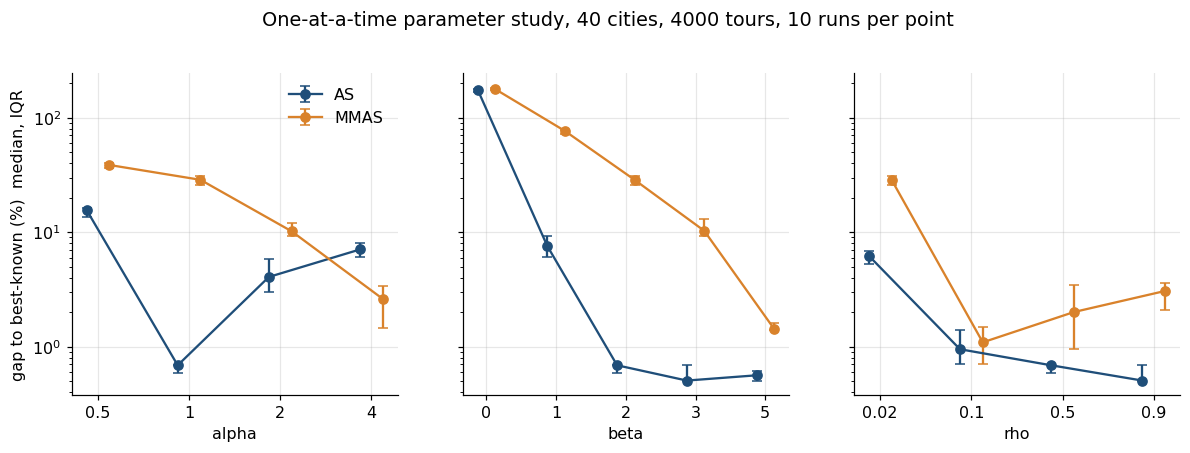

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, p in zip(axes, grids):
    for k, var in enumerate(["AS", "MMAS"]):
        g = study_res[var, p]
        x = np.arange(len(grids[p])) + (k - 0.5) * 0.25
        med = [np.median(v) for v in g]
        lo_ = [np.median(v) - np.percentile(v, 25) for v in g]; hi_ = [np.percentile(v, 75) - np.median(v) for v in g]
        ax.errorbar(x, med, yerr=[lo_, hi_], fmt="o-", capsize=3, label=var, color=list(PALETTE.values())[k])
    ax.set_xticks(range(len(grids[p]))); ax.set_xticklabels(grids[p]); ax.set_xlabel(p)
axes[0].set_ylabel("gap to best-known (%)  median, IQR"); axes[0].legend()
axes[0].set_yscale("log")
plt.suptitle("One-at-a-time parameter study, 40 cities, 4000 tours, 10 runs per point", y=1.03)
savefig("w5_aco_parameter_study.png"); plt.show()

**Reading the study.** $\beta=0$ (no heuristic) is by far the worst setting for both variants: with 4000 tours the
pheromone alone cannot discover good edges among $\binom{40}{2}=780$, so the greedy information $\eta$ is
essential. For **AS** the classic setting $\alpha=1$ is best; $\alpha\ge2$ over-trusts the early, noisy pheromone
(stagnation) and $\alpha=0.5$ learns too little; AS needs strong evaporation ($\rho\ge0.1$) to forget the deposits of
its many mediocre ants. **MMAS** with the literature default $\rho=0.02$ is poor at this budget: its model starts
uniform at $\tau_{\max}$ and 100 iterations are far too few to concentrate it. Everything that speeds up concentration
— larger $\alpha$, larger $\beta$, or $\rho=0.1$ — helps enormously. The MMAS defaults were designed for long runs
(thousands of iterations) where slow, careful learning pays off. Parameter conclusions are budget-dependent, which is
why tuning (Week 6) must be done at the budget of intended use.

## 7. ACO + 2-opt local search at equal cost

In practice ACO is almost always combined with local search (Dorigo & Gambardella 1997 used 3-opt in ACS;
Stützle & Hoos 2000 used 2-opt/3-opt in MMAS): ants provide good *starting points* and local search removes
crossings. Cost accounting: a tour construction/evaluation costs 1 unit (it reads $n$ distances), and a 2-opt move
evaluation reads 4 distances, i.e. $4/n$ units. Budget: 6000 units on a 100-city instance; 8 runs each for
* MMAS (no local search, $m=25$ ants, $\rho=0.1$ — its best evaporation rate in the parameter study above, so the
  comparison is not won against a badly tuned baseline),
* MMAS + 2-opt ($m=10$, $\rho=0.2$ as recommended with local search),
* multistart 2-opt from uniformly random tours (no learning) — the control that isolates the value of the pheromone.

In [10]:
pts100, D100 = random_euclidean_tsp(100, np.random.default_rng(60))
UNITS = 6000
nb100 = neighbour_lists(D100, 10)

def best_at_budget(res, units):
    """Best length of each run using only iterations whose cumulative cost is <= units."""
    k = (res["cost"] <= units).sum(1) - 1
    return res["hist"][np.arange(len(k)), k]

r_ls = aco_tsp(D100, "MMAS", runs=8, iters=10**6, m=10, rho=0.2, local_search=True, rng=np.random.default_rng(61),
               max_cost=UNITS)
ls_best = best_at_budget(r_ls, UNITS)
r_plain = aco_tsp(D100, "MMAS", runs=8, iters=UNITS // 25, m=25, rho=0.1, rng=np.random.default_rng(62))
ms_best, ms_curves, ms_descents = [], [], []
for s_ in range(8):
    g = np.random.default_rng(700 + s_); spent, best, curve = 0.0, np.inf, []
    while True:
        t1, ev, _ = two_opt_nl(g.permutation(100), D100, nb100)
        spent += 1 + ev * 4 / 100
        if spent > UNITS:
            break
        best = min(best, tour_length(t1, D100)); curve.append((spent, best))
    ms_best.append(best); ms_curves.append(np.array(curve)); ms_descents.append(len(curve))
ms_best = np.array(ms_best)
L100 = min(ls_best.min(), r_plain["best_len"].min(), ms_best.min())
print(f"best-known length {L100:.4f};  2-opt descents within the budget: MMAS+2-opt "
      f"{10 * np.median((r_ls['cost'] <= UNITS).sum(1)):.0f} (median), multistart {np.median(ms_descents):.0f} (median)")
for name, v in [("MMAS (no LS)", r_plain["best_len"]), ("MMAS + 2-opt", ls_best), ("multistart 2-opt", ms_best)]:
    g = 100 * (v / L100 - 1)
    print(f"  {name:18s} gap median {np.median(g):5.2f}%  IQR [{np.percentile(g, 25):.2f}, {np.percentile(g, 75):.2f}]")
print(f"Mann-Whitney p: MMAS+2opt vs MMAS {mannwhitneyu(ls_best, r_plain['best_len']).pvalue:.1e}, "
      f"MMAS+2opt vs multistart 2-opt {mannwhitneyu(ls_best, ms_best).pvalue:.1e}")
check_true(np.median(ls_best) < np.median(r_plain["best_len"]), "MMAS + 2-opt beats plain MMAS at equal cost (median)")
check_true(np.median(ls_best) < np.median(ms_best), "MMAS + 2-opt beats multistart 2-opt at equal cost (median)")

best-known length 8.3476;  2-opt descents within the budget: MMAS+2-opt 240 (median), multistart 146 (median)
  MMAS (no LS)       gap median  2.83%  IQR [1.59, 3.68]
  MMAS + 2-opt       gap median  0.29%  IQR [0.03, 0.42]
  multistart 2-opt   gap median  1.39%  IQR [1.04, 1.64]
Mann-Whitney p: MMAS+2opt vs MMAS 6.2e-04, MMAS+2opt vs multistart 2-opt 1.1e-03
[PASS] MMAS + 2-opt beats plain MMAS at equal cost (median)
[PASS] MMAS + 2-opt beats multistart 2-opt at equal cost (median)


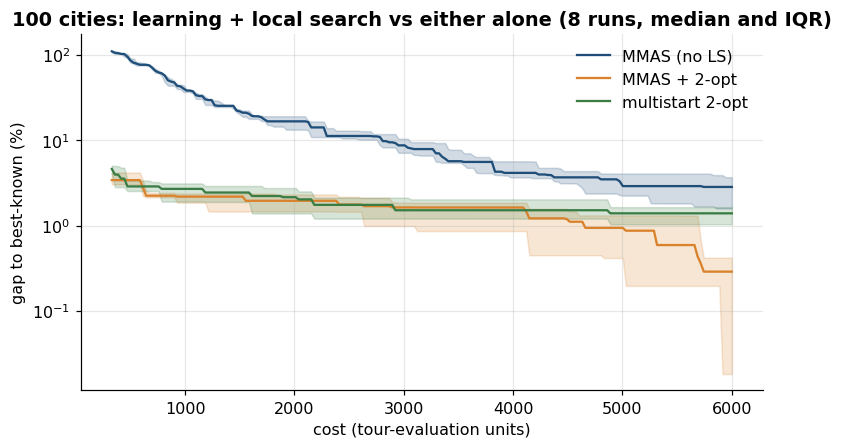

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.2))
u0 = max(r_plain["cost"][:, 0].max(), r_ls["cost"][:, 0].max(), max(c[0, 0] for c in ms_curves))
grid_u = np.linspace(u0, UNITS, 200)        # start where every run of every method has a first value
def on_grid(cost, hist):
    k = np.searchsorted(cost, grid_u, side="right") - 1
    return np.where(k >= 0, hist[np.maximum(k, 0)], np.nan)
curves = {"MMAS (no LS)": np.array([on_grid(c, h) for c, h in zip(r_plain["cost"], r_plain["hist"])]),
          "MMAS + 2-opt": np.array([on_grid(c, h) for c, h in zip(r_ls["cost"], r_ls["hist"])]),
          "multistart 2-opt": np.array([on_grid(c[:, 0], c[:, 1]) for c in ms_curves])}
for k, (name, Y) in enumerate(curves.items()):
    q1, m_, q3 = np.nanpercentile(100 * (Y / L100 - 1), [25, 50, 75], axis=0)
    ax.plot(grid_u, m_, label=name, color=list(PALETTE.values())[k])
    ax.fill_between(grid_u, q1, q3, alpha=0.2, color=list(PALETTE.values())[k])
ax.set_xlabel("cost (tour-evaluation units)"); ax.set_ylabel("gap to best-known (%)"); ax.set_yscale("symlog", linthresh=0.1)
ax.set_title("100 cities: learning + local search vs either alone (8 runs, median and IQR)"); ax.legend()
savefig("w5_aco_local_search.png"); plt.show()

**Reading the comparison.** Even with its evaporation rate tuned for short runs, plain MMAS is still several percent
above the best-known tour after 6000 constructions on 100 cities: sampling alone repairs local defects slowly. Multistart 2-opt is a strong baseline because each descent is cheap with neighbour lists, but its
starting points carry no information. MMAS + 2-opt starts its descents from tours sampled near the best tours found
so far, so each descent is short (cheap) *and* lands in a better region: it wins at equal cost with a clear
Mann–Whitney p-value. This division of labour — a learned sampling distribution proposes, local search
repairs — is the standard architecture of state-of-the-art ACO.

## Key takeaways

- ACO = repeated sampling from a constructive Markov model $p_{ij}\propto\tau_{ij}^\alpha\eta_{ij}^\beta$ whose
  parameters $\tau$ are learned by evaporation (forgetting) and deposit (reinforcement of sampled good solutions).
- AS, ACS and MMAS differ in *who deposits* and in how exploitation is controlled: ACS by the greedy rule $q_0$ and the
  local update, MMAS by the bounds $[\tau_{\min},\tau_{\max}]$ with $\tau_{\max}=1/(\rho L_{\text{bs}})$ (the fixed point of
  evaporation + deposit) and restarts.
- On 13-city instances AS, ACS and MMAS recover the Held–Karp optimum in 92–98% of runs within 1500 tours.
- The heuristic $\eta$ is indispensable ($\beta=0$ fails); $\alpha$ and $\rho$ trade learning speed against stagnation,
  and their best values depend on the budget.
- Pheromone + local search is far stronger than either alone at equal cost: ACO supplies starting points
  concentrated near good tours, 2-opt removes the local defects that sampling cannot fix cheaply.

## Exercises

1. ★ Prove that in AS with constant deposits the pheromone of an edge never used after iteration $t_0$ decays as
   $(1-\rho)^{t-t_0}$ and compute after how many iterations it falls below $\tau_{\min}$ of MMAS.
2. ★ Show that the ACS global update $\tau\leftarrow(1-\rho)\tau+\rho/L_{bs}$ keeps every pheromone value in
   $[\tau_0, 1/L_{bs}]$ when $\tau_0\le1/L_{bs}$ (local and global updates are both convex combinations).
3. ★★ Implement candidate lists (restrict the choice to the 15 nearest unvisited cities, falling back to all cities)
   and measure the speed-up and the quality change on 100 cities at equal tour budgets.
4. ★★ Replace iteration-best deposit in MMAS by a schedule alternating iteration-best and best-so-far
   (Stützle & Hoos 2000) and compare on the 100-city instance of Section 7 with 2-opt (8 seeds, equal cost).
5. ★★ Define the average $\lambda$-branching factor (Gambardella & Dorigo 1995) and implement it as MMAS's restart
   criterion. Plot it over time next to the mean row entropy.
6. ★★★ Apply MMAS to the asymmetric TSP (random asymmetric distance matrix) — which parts of the implementation
   assume symmetry? — and validate against Held–Karp on $n\le12$ (the DP works unchanged for asymmetric costs).